In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape of dataset: ", df.shape)
print("\nColumns: ", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

print("\nData Info: ")
print(df.info())
print("\nMissing Values : ")
print(df.isnull(). sum())

Shape of dataset:  (7043, 21)

Columns:  ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...        

In [3]:
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nChurn Distribution:")
print(df['Churn'].value_counts())
print("\nChurn Percentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

Dataset Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [4]:
print("Data Types:\n")
print(df.dtypes)

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nTotalCharges column info:")
print(df['TotalCharges'].head(10))
print("\nTotalCharges unique values sample:")
print(df['TotalCharges'].unique()[:20])

print("\nNumber of blank spaces in TotalCharges:", 
      (df['TotalCharges'] == ' ').sum())

Data Types:

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing Values:

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBillin

In [5]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nTotalCharges data type now:", df['TotalCharges'].dtype)

Missing values after cleaning:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

TotalCharges data type now: float64


In [6]:
median_total = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_total)
print("\nMissing Values after filling :")
print(df.isnull().sum())
print("\nTotalCharges summary: ")
print(df['TotalCharges'].describe())


Missing Values after filling :
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

TotalCharges summary: 
count    7043.000000
mean     2281.916928
std      2265.270398
min        18.800000
25%       402.225000
50%      1397.475000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64


In [8]:
print("Numerical columns summary: ")
print(df.describe())
print("\nChurn Rate by Contract Type:")
print(df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack())
print("\nChurn Rate by Internet Service:")
print(df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack())
print("\nAverage Monthly Charges:")
print(df.groupby('Churn')['MonthlyCharges'].mean())

Numerical columns summary: 
       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7043.000000
mean        0.162147    32.371149       64.761692   2281.916928
std         0.368612    24.559481       30.090047   2265.270398
min         0.000000     0.000000       18.250000     18.800000
25%         0.000000     9.000000       35.500000    402.225000
50%         0.000000    29.000000       70.350000   1397.475000
75%         0.000000    55.000000       89.850000   3786.600000
max         1.000000    72.000000      118.750000   8684.800000

Churn Rate by Contract Type:
Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887305  0.112695
Two year        0.971681  0.028319

Churn Rate by Internet Service:
Churn                  No       Yes
InternetService                    
DSL              0.810409  0.189591
Fiber optic      0.581072  0.418928
No            

In [9]:
df['tenure_group'] = pd.cut(df['tenure'], 
                           bins=[0, 12, 24, 48, 72, 100], 
                           labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr', '6+yr'])

print("Tenure Group Distribution:")
print(df['tenure_group'].value_counts())

print("\nChurn Rate by Tenure Group:")
print(df.groupby('tenure_group')['Churn'].value_counts(normalize=True).unstack())

Tenure Group Distribution:
tenure_group
4-6yr    2239
0-1yr    2175
2-4yr    1594
1-2yr    1024
6+yr        0
Name: count, dtype: int64

Churn Rate by Tenure Group:
Churn               No       Yes
tenure_group                    
0-1yr         0.523218  0.476782
1-2yr         0.712891  0.287109
2-4yr         0.796110  0.203890
4-6yr         0.904868  0.095132


In [10]:
df = df.drop('customerID', axis=1)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Final Columns after cleaning:")
print(df.columns.tolist())

print("\nChurn Distribution (0 = Stayed, 1 = Churned):")
print(df['Churn'].value_counts())

Final Columns after cleaning:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_group']

Churn Distribution (0 = Stayed, 1 = Churned):
Churn
0    5174
1    1869
Name: count, dtype: int64


In [11]:
categorical_columns = ['gender', 'Partner', 'Dependents', 'PhoneService', 
                      'MultipleLines', 'InternetService', 'OnlineSecurity', 
                      'OnlineBackup', 'DeviceProtection', 'TechSupport', 
                      'StreamingTV', 'StreamingMovies', 'Contract', 
                      'PaperlessBilling', 'PaymentMethod']

df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

print("Shape after encoding:", df.shape)
print("\nFirst few column names after encoding:")
print(df.columns.tolist()[:15])  
print("\nLast few column names:")
print(df.columns.tolist()[-10:])

Shape after encoding: (7043, 32)

First few column names after encoding:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_group', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service']

Last few column names:
['StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [12]:
print("=== Final Dataset Status ===")
print("Shape:", df.shape)
print("\nMissing Values Total:", df.isnull().sum().sum())

print("\nData Types Summary:")
print(df.dtypes.value_counts())

print("\nChurn Distribution (0 = Stayed, 1 = Churned):")
print(df['Churn'].value_counts(normalize=True) * 100)

=== Final Dataset Status ===
Shape: (7043, 32)

Missing Values Total: 11

Data Types Summary:
bool        26
int64        3
float64      2
category     1
Name: count, dtype: int64

Churn Distribution (0 = Stayed, 1 = Churned):
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [13]:
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
                   'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                   'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 
                   'PaperlessBilling', 'PaymentMethod']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", df.shape)
print("\nLast 10 new columns:")
print(df.columns[-10:].tolist())

KeyError: "None of [Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',\n       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',\n       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',\n       'PaperlessBilling', 'PaymentMethod'],\n      dtype='str')] are in the [columns]"

In [14]:
print("Actual columns in your dataframe:")
print(df.columns.tolist())

Actual columns in your dataframe:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_group', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [15]:
print(df.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_group', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [16]:
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
                   'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                   'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 
                   'PaperlessBilling', 'PaymentMethod']

available_cols = [col for col in categorical_cols if col in df.columns]

df = pd.get_dummies(df, columns=available_cols, drop_first=True)

print("Shape after encoding:", df.shape)
print("New columns created:", len(df.columns) - 21)

Shape after encoding: (7043, 32)
New columns created: 11


In [17]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Churn rate in training set:", y_train.mean())
print("Churn rate in test set:", y_test.mean())

Training set shape: (5634, 31)
Test set shape: (1409, 31)
Churn rate in training set: 0.2655307064252751
Churn rate in test set: 0.26472675656493966


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training models...\n")

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("\nRandom Forest Results:")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Training models...



ValueError: Cannot cast str dtype to float64

In [19]:
# Drop the tenure_group column (since it's text)
df = df.drop('tenure_group', axis=1, errors='ignore')

print("Shape after dropping tenure_group:", df.shape)
print("All columns are numeric now?", df.select_dtypes(include='object').shape[1] == 0)

Shape after dropping tenure_group: (7043, 31)
All columns are numeric now? True


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training models...\n")

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("\nRandom Forest Results:")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Training models...



C:\Users\saifh\sales-inventory-app\churn-prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Results:
Accuracy: 0.8211497515968772
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409


Random Forest Results:
Accuracy: 0.7892122072391767
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.64      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training models...\n")

log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)

print("Logistic Regression Results:")
print("Accuracy:", round(accuracy_score(y_test, log_pred), 4))
print(classification_report(y_test, log_pred))

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("\nRandom Forest Results:")
print("Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print(classification_report(y_test, rf_pred))

Training models...

Logistic Regression Results:
Accuracy: 0.8197
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409


Random Forest Results:
Accuracy: 0.7935
              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1036
           1       0.66      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Prepare features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining models...\n")

# 1. Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

print("Logistic Regression Accuracy:", round(accuracy_score(y_test, log_pred), 4))
print(classification_report(y_test, log_pred))

# 2. Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("\nRandom Forest Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print(classification_report(y_test, rf_pred))

Training set shape: (5634, 30)
Test set shape: (1409, 30)

Training models...



C:\Users\saifh\sales-inventory-app\churn-prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.8211
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409


Random Forest Accuracy: 0.7935
              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1036
           1       0.66      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Prepare data
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data (this usually fixes the warning)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training models...\n")

# 1. Logistic Regression with scaling + more iterations
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", round(accuracy_score(y_test, log_pred), 4))
print(classification_report(y_test, log_pred))

# 2. Random Forest (usually doesn't need scaling)
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("\nRandom Forest Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print(classification_report(y_test, rf_pred))

Training models...

Logistic Regression Accuracy: 0.8197
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409


Random Forest Accuracy: 0.7935
              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1036
           1       0.66      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Prepare data
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training improved models...\n")

# 1. Improved Logistic Regression
log_model = LogisticRegression(max_iter=2000, class_weight='balanced')
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)

print("Logistic Regression (Improved):")
print("Accuracy:", round(accuracy_score(y_test, log_pred), 4))
print(classification_report(y_test, log_pred))

# 2. Improved Random Forest
rf_model = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("\nRandom Forest (Improved):")
print("Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print(classification_report(y_test, rf_pred))

Training improved models...

Logistic Regression (Improved):
Accuracy: 0.7473
              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1036
           1       0.51      0.82      0.63       373

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409


Random Forest (Improved):
Accuracy: 0.7828
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1036
           1       0.58      0.64      0.61       373

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.79      1409



Top 10 Most Important Features:
                           feature  importance
3                     TotalCharges    0.182245
1                           tenure    0.164999
2                   MonthlyCharges    0.153375
25               Contract_Two year    0.060053
10     InternetService_Fiber optic    0.040715
28  PaymentMethod_Electronic check    0.035432
24               Contract_One year    0.028465
13              OnlineSecurity_Yes    0.028339
4                      gender_Male    0.025713
26            PaperlessBilling_Yes    0.023906


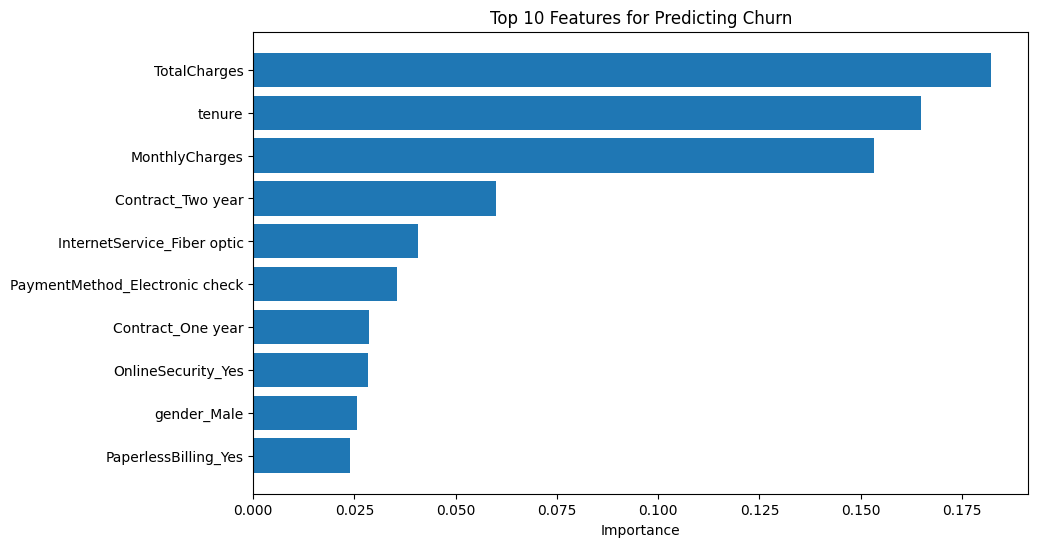

In [26]:
import matplotlib.pyplot as plt

# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'][:10], feature_importance['importance'][:10])
plt.title('Top 10 Features for Predicting Churn')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

In [27]:
import joblib

# Save the best model (Logistic Regression in your case)
joblib.dump(log_model, 'churn_model.pkl')

# Also save the scaler (very important)
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [28]:
def predict_churn(new_customer_data):
    # new_customer_data should be a DataFrame with same columns as training data
    scaled_data = scaler.transform(new_customer_data)
    prediction = log_model.predict(scaled_data)
    probability = log_model.predict_proba(scaled_data)[:, 1]
    
    return {
        "will_churn": "Yes" if prediction[0] == 1 else "No",
        "churn_probability": round(probability[0] * 100, 2)
    }

print("Prediction function ready!")

Prediction function ready!


In [29]:
import joblib

# Save the best model (Logistic Regression)
joblib.dump(log_model, 'churn_model.pkl')

# Save the scaler (very important)
joblib.dump(scaler, 'scaler.pkl')

print("✅ Model and scaler saved successfully!")
print("Files saved: churn_model.pkl and scaler.pkl")

✅ Model and scaler saved successfully!
Files saved: churn_model.pkl and scaler.pkl


In [30]:
def predict_churn(new_customer):
    """
    Predict if a new customer will churn
    new_customer should be a DataFrame with the same columns as training data
    """
    # Scale the new data
    scaled_data = scaler.transform(new_customer)
    
    # Make prediction
    prediction = log_model.predict(scaled_data)
    probability = log_model.predict_proba(scaled_data)[:, 1]
    
    result = {
        "will_churn": "Yes" if prediction[0] == 1 else "No",
        "churn_probability": round(probability[0] * 100, 2)
    }
    
    return result

print("✅ Prediction function created successfully!")

✅ Prediction function created successfully!


In [31]:
# Example: Create one new customer data
new_customer = pd.DataFrame({
    'tenure': [5],
    'MonthlyCharges': [70.5],
    'TotalCharges': [352.5],
    # ... add other columns with proper values
})

result = predict_churn(new_customer)
print(result)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- Contract_One year
- Contract_Two year
- Dependents_Yes
- DeviceProtection_No internet service
- DeviceProtection_Yes
- ...


In [32]:
# Create a proper new customer with all required columns
new_customer = pd.DataFrame({
    'tenure': [12],
    'MonthlyCharges': [65.5],
    'TotalCharges': [786.0],
    # Add all other necessary columns with default values
}, index=[0])

# Add missing one-hot encoded columns with 0
for col in X.columns:
    if col not in new_customer.columns:
        new_customer[col] = 0

# Make sure columns are in the same order as training data
new_customer = new_customer[X.columns]

print("New customer data shape:", new_customer.shape)

# Now make prediction
result = predict_churn(new_customer)
print(result)

New customer data shape: (1, 30)
{'will_churn': 'No', 'churn_probability': np.float64(38.96)}
